# Import Semua Library yang Dibutuhkan
Pada tahap awal, kita mengimpor semua pustaka (library) yang diperlukan. Mengumpulkan semua impor di awal adalah praktik terbaik agar kode lebih rapi dan mudah dikelola.

In [13]:
# Import library yang diperlukan
# 1. Library dasar untuk operasi file dan manipulasi array
import os                 # Untuk operasi sistem file
import shutil            # Untuk operasi copy file
import numpy as np       # Untuk operasi numerik dan array
import matplotlib.pyplot as plt  # Untuk visualisasi

# 2. Library TensorFlow dan komponen-komponennya
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Untuk augmentasi data
from tensorflow.keras.applications import MobileNetV2              # Model pre-trained
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 3. Library untuk analisis dan metrik
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

# 4. Library tambahan
import random
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Set random seed untuk reproducibility (hasil yang konsisten)
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [14]:
# Kode untuk membagi dataset menjadi train, validation, dan test sets

# Definisikan path untuk dataset
dataset_dir = "data"              # Direktori sumber dataset
output_dir = "dataset_split"      # Direktori output untuk data yang sudah dibagi

# Buat struktur folder untuk train, validation, dan test
for split in ["train", "val", "test"]:
    split_dir = os.path.join(output_dir, split)
    os.makedirs(split_dir, exist_ok=True)  # Buat folder jika belum ada
    
    # Buat subfolder untuk setiap kelas di dalam setiap split
    for kelas in os.listdir(dataset_dir):
        os.makedirs(os.path.join(split_dir, kelas), exist_ok=True)

# Proses setiap kelas dalam dataset
for kelas in os.listdir(dataset_dir):
    kelas_dir = os.path.join(dataset_dir, kelas)
    images = os.listdir(kelas_dir)
    random.shuffle(images)  # Acak urutan gambar

    # Hitung jumlah gambar untuk setiap split (80% train, 10% validation, 10% test)
    total = len(images)
    train_count = int(0.8 * total)
    val_count = int(0.1 * total)

    # Bagi gambar ke dalam train, validation, dan test sets
    train_files = images[:train_count]
    val_files = images[train_count:train_count + val_count]
    test_files = images[train_count + val_count:]

    # Copy file ke folder yang sesuai
    for f in train_files:
        shutil.copy(os.path.join(kelas_dir, f), os.path.join(output_dir, "train", kelas, f))
    for f in val_files:
        shutil.copy(os.path.join(kelas_dir, f), os.path.join(output_dir, "val", kelas, f))
    for f in test_files:
        shutil.copy(os.path.join(kelas_dir, f), os.path.join(output_dir, "test", kelas, f))

print("✅ Dataset berhasil dibagi menjadi Train/Val/Test (80/10/10) secara proporsional")

✅ Dataset berhasil dibagi menjadi Train/Val/Test (80/10/10) secara proporsional


# Konfigurasi Path, Parameter, dan Nama Model
Di sel ini, kita mengatur semua variabel global yang akan digunakan di seluruh notebook, seperti path ke dataset, ukuran gambar, dan nama file untuk model yang akan kita simpan. Dengan cara ini, jika Anda ingin mengubah sesuatu (misalnya, nama model untuk eksperimen baru), Anda hanya perlu mengubahnya di satu tempat.

In [15]:
# Konfigurasi path dan parameter global

# Definisikan path dasar untuk dataset yang sudah dibagi
BASE_PATH = 'dataset_split'
train_dir = os.path.join(BASE_PATH, 'train')
val_dir = os.path.join(BASE_PATH, 'val')
test_dir = os.path.join(BASE_PATH, 'test')

# Fungsi untuk menampilkan struktur direktori secara visual
def print_directory_structure(path, indent=""):
    if os.path.exists(path):
        print(f"{indent}📂 {os.path.basename(path)}")
        try:
            for item in os.listdir(path):
                item_path = os.path.join(path, item)
                if os.path.isdir(item_path):
                    print_directory_structure(item_path, indent + "  ")
                else:
                    print(f"{indent}  📄 {item}")
        except Exception as e:
            print(f"{indent}  ❌ Error reading directory: {str(e)}")
    else:
        print(f"{indent}❌ Path tidak ditemukan: {path}")

# Tampilkan struktur dataset
print("Struktur Dataset:")
print_directory_structure(BASE_PATH)

# Parameter model dan training
MODEL_NAME = 'revisi.h5'  
IMAGE_SIZE = 224                       # Ukuran gambar input (224x224 piksel)
BATCH_SIZE = 16                       # Jumlah gambar per batch
EPOCHS = 100                          # Jumlah epoch maksimum untuk training

# Deteksi kelas dari direktori training
if os.path.exists(train_dir):
    CLASSES = sorted(os.listdir(train_dir))  # Dapatkan nama kelas dari folder
    print(f"\nKelas yang terdeteksi: {CLASSES}")
    print(f"Jumlah kelas: {len(CLASSES)}")
else:
    print("\nWarning: Training directory tidak ditemukan!")
    CLASSES = []

Struktur Dataset:
📂 dataset_split
  📂 test
    📂 healthy
      📄 Healthy Leaf00020.JPG
      📄 Healthy Leaf00096.JPG
      📄 Healthy Leaf00104.JPG
      📄 Healthy Leaf00116.JPG
      📄 Healthy Leaf00177.JPG
      📄 Healthy Leaf00193.JPG
      📄 Healthy Leaf00206.JPG
      📄 IMG_20210421_090934_jpg.rf.9b3fea5d9ab3c0e9c76a6f24ff353fc2.jpg
      📄 IMG_20210421_091233_jpg.rf.9d866303c1745899abc8da531f604084.jpg
      📄 IMG_20210421_091927_jpg.rf.0062a8b03036f1eb159730770acc62da.jpg
      📄 IMG_20210421_093648_jpg.rf.d3b374af3ab8c071208055480f722f3d.jpg
      📄 sehat-117-_jpg.rf.9f826a63a83d2ccc90b2f2e3a7f44d4a.jpg
    📂 leaf curl
      📄 Curl Virus00137.JPG
      📄 Curl Virus00171.JPG
      📄 Curl Virus00172.JPG
      📄 Curl Virus00231.JPG
      📄 Curl Virus00262.JPG
      📄 Curl Virus00276.JPG
      📄 Curl Virus00358.JPG
      📄 Curl Virus00384.JPG
      📄 Curl Virus00388.JPG
      📄 Curl Virus00410.JPG
      📄 download (9).jpg
      📄 images (19)a.jpg
      📄 images (21)a.jpg
      📄 ima

# Persiapan Data (Data Augmentation & Generators)
Langkah ini sangat krusial. Kita akan menyiapkan "pipa" data menggunakan ImageDataGenerator. Untuk data training, kita akan menerapkan augmentasi data (memutar, zoom, flip) untuk membuat model lebih tangguh dan mencegah overfitting. Untuk data validasi dan test, kita hanya melakukan pra-pemrosesan tanpa augmentasi.

In [16]:
# Persiapan Data Generator dan Augmentasi

# Generator untuk data training dengan augmentasi yang lebih kuat
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Preprocessing MobileNetV2
    rotation_range=30,      # Rotasi gambar hingga 30 derajat
    width_shift_range=0.2,  # Geser horizontal hingga 20%
    height_shift_range=0.2, # Geser vertikal hingga 20%
    shear_range=0.2,       # Transformasi shear
    zoom_range=0.2,        # Zoom in/out hingga 20%
    horizontal_flip=True,   # Flip horizontal
    vertical_flip=True,    # Tambahkan flip vertikal
    fill_mode='nearest',   # Metode mengisi pixel yang kosong
    brightness_range=[0.8, 1.2]  # Variasi kecerahan
)

# Generator untuk validasi dan testing (tanpa augmentasi)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

try:
    # Siapkan generator untuk data training
    print("Memuat data training...")
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=seed  
    )
    
    # Siapkan generator untuk data validasi
    print("\nMemuat data validasi...")
    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    # Siapkan generator untuk data testing
    print("\nMemuat data testing...")
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    # Tampilkan informasi jumlah sampel
    print("\nJumlah sampel:")
    print(f"Training: {train_generator.samples}")
    print(f"Validasi: {val_generator.samples}")
    print(f"Testing: {test_generator.samples}")
    
except FileNotFoundError as e:
    print(f"Error: Directory tidak ditemukan. Pastikan struktur folder benar:\n{str(e)}")
except Exception as e:
    print(f"Error saat memuat data: {str(e)}")

Memuat data training...
Found 443 images belonging to 5 classes.
Found 443 images belonging to 5 classes.

Memuat data validasi...
Found 54 images belonging to 5 classes.

Memuat data validasi...
Found 54 images belonging to 5 classes.

Memuat data testing...
Found 59 images belonging to 5 classes.

Jumlah sampel:
Training: 443
Validasi: 54
Testing: 59

Memuat data testing...
Found 59 images belonging to 5 classes.

Jumlah sampel:
Training: 443
Validasi: 54
Testing: 59


In [17]:
# Hitung class weights untuk menangani ketidakseimbangan kelas

# Dapatkan indeks kelas dari generator training
class_indices = train_generator.classes

# Hitung bobot untuk setiap kelas menggunakan 'balanced' strategy
class_weights = compute_class_weight(
    class_weight='balanced',      # Gunakan strategi 'balanced'
    classes=np.unique(class_indices),  # Daftar kelas unik
    y=class_indices              # Label kelas untuk setiap sampel
)

# Konversi bobot ke dalam format dictionary untuk digunakan dalam training
class_weights_dict = dict(enumerate(class_weights))
print(f"Class Weights: {class_weights_dict}")

Class Weights: {0: np.float64(1.0068181818181818), 1: np.float64(0.7637931034482759), 2: np.float64(1.1215189873417721), 3: np.float64(1.1075), 4: np.float64(1.1075)}


# Membangun Arsitektur Model (Transfer Learning MobileNetV2)
Di sini kita membangun "otak" dari sistem kita. Kita menggunakan Transfer Learning dengan model MobileNetV2 yang sudah terlatih pada ImageNet. Kita "membekukan" lapisan dasar MobileNetV2 dan hanya melatih beberapa lapisan baru di atasnya.

In [18]:
# Membangun arsitektur model dengan Transfer Learning dan Regularisasi
from tensorflow.keras.regularizers import l2

# Inisialisasi model dasar MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',           # Gunakan bobot pre-trained dari ImageNet
    include_top=False,           # Tidak menggunakan layer classifier asli
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)  # Ukuran input gambar RGB
)
base_model.trainable = False    # Bekukan layer MobileNetV2

# Bangun arsitektur model lengkap dengan regularisasi
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

# Tambahkan regularisasi L2 dan tingkatkan dropout
x = Dropout(0.6)(x)  # Tingkatkan dropout rate
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
outputs = Dense(len(CLASSES), activation='softmax')(x)

# Buat model final
model = Model(inputs, outputs)

# Kompilasi model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Learning rate kecil
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan ringkasan arsitektur model
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Implementasi K-Fold Cross Validation
Sebelum melakukan training penuh, kita akan menggunakan K-Fold Cross Validation untuk mendapatkan estimasi performa model yang lebih robust. Teknik ini akan membagi data training menjadi beberapa bagian dan melakukan validasi silang.

In [19]:
# Import KFold dari sklearn
from sklearn.model_selection import KFold
import time

# Fungsi untuk membuat model
def create_model():
    """Fungsi untuk membuat dan mengkompilasi model"""
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(len(CLASSES), activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Konfigurasi cross validation
n_splits = 5  # Jumlah fold
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

# List untuk menyimpan hasil
fold_accuracies = []
fold_losses = []
fold_histories = []
fold_durations = []

# Kumpulkan semua file dan label dari direktori training
all_files = []
all_labels = []

for class_idx, class_name in enumerate(CLASSES):
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        all_files.append(os.path.join(class_path, img_name))
        all_labels.append(class_idx)

all_files = np.array(all_files)
all_labels = np.array(all_labels)

In [20]:
# Implementasi K-Fold Cross Validation
print(f"\nMemulai {n_splits}-Fold Cross Validation")

# Catat waktu mulai keseluruhan proses
total_start_time = time.time()

# Buat temporary direktori untuk fold
temp_train_dir = os.path.join(BASE_PATH, 'temp_train')
temp_val_dir = os.path.join(BASE_PATH, 'temp_val')

# Untuk menyimpan model terbaik dan tracking waktu
best_val_acc = 0
best_fold_model = None
fold_times = []  # Untuk menyimpan waktu setiap fold

# List untuk tracking rata-rata waktu
completed_fold_times = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(all_files)):
    current_fold = fold + 1
    print(f"\n{'='*50}")
    print(f"Memulai Fold {current_fold}/{n_splits}")
    print(f"{'='*50}")
    
    fold_start_time = time.time()
    
    # 1. Pembuatan Model
    print("\n1. Membuat model...")
    model_start_time = time.time()
    fold_model = create_model()
    model_creation_time = time.time() - model_start_time
    print(f"✓ Model dibuat dalam waktu: {model_creation_time:.2f} detik")
    
    # 2. Persiapan Data
    print("\n2. Menyiapkan data...")
    data_prep_start = time.time()
    
    # Buat dan bersihkan direktori temporary
    os.makedirs(temp_train_dir, exist_ok=True)
    os.makedirs(temp_val_dir, exist_ok=True)
    
    for d in [temp_train_dir, temp_val_dir]:
        if os.path.exists(d):
            for item in os.listdir(d):
                item_path = os.path.join(d, item)
                if os.path.isdir(item_path):
                    shutil.rmtree(item_path)
    
    # Buat subdirektori untuk setiap kelas
    for class_name in CLASSES:
        os.makedirs(os.path.join(temp_train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(temp_val_dir, class_name), exist_ok=True)
    
    # Pindahkan file sesuai fold
    for idx in train_idx:
        src_file = all_files[idx]
        class_name = os.path.basename(os.path.dirname(src_file))
        dst_file = os.path.join(temp_train_dir, class_name, os.path.basename(src_file))
        shutil.copy2(src_file, dst_file)
    
    for idx in val_idx:
        src_file = all_files[idx]
        class_name = os.path.basename(os.path.dirname(src_file))
        dst_file = os.path.join(temp_val_dir, class_name, os.path.basename(src_file))
        shutil.copy2(src_file, dst_file)
    
    # Buat generators
    train_gen = train_datagen.flow_from_directory(
        temp_train_dir,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
    
    val_gen = val_datagen.flow_from_directory(
        temp_val_dir,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    data_prep_time = time.time() - data_prep_start
    print(f"✓ Data disiapkan dalam waktu: {data_prep_time:.2f} detik")
    
    # 3. Training Model
    print("\n3. Memulai proses training...")
    train_start_time = time.time()
    
    history = fold_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )],
        verbose=1
    )
    
    train_time = time.time() - train_start_time
    print(f"\n✓ Training selesai dalam waktu: {train_time/60:.2f} menit")
    
    # 4. Evaluasi Model
    print("\n4. Melakukan evaluasi...")
    eval_start_time = time.time()
    val_loss, val_acc = fold_model.evaluate(val_gen, verbose=0)
    eval_time = time.time() - eval_start_time
    
    # Update model terbaik jika perlu
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_fold_model = fold_model
        print(f"\n✨ Model fold ini menjadi model terbaik dengan akurasi: {val_acc:.4f}")
    
    # Hitung waktu total fold ini
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    completed_fold_times.append(fold_time)
    
    # Simpan metrics
    fold_accuracies.append(val_acc)
    fold_losses.append(val_loss)
    fold_histories.append(history.history)
    fold_durations.append(fold_time)
    
    # Tampilkan ringkasan waktu untuk fold ini
    print(f"\n{'='*50}")
    print(f"Ringkasan Fold {current_fold}/{n_splits}")
    print(f"{'='*50}")
    print(f"├── Waktu pembuatan model: {model_creation_time:.2f} detik")
    print(f"├── Waktu persiapan data: {data_prep_time:.2f} detik")
    print(f"├── Waktu training: {train_time/60:.2f} menit")
    print(f"├── Waktu evaluasi: {eval_time:.2f} detik")
    print(f"├── Total waktu fold: {fold_time/60:.2f} menit")
    print(f"├── Akurasi: {val_acc:.4f}")
    print(f"└── Loss: {val_loss:.4f}")
    
    # Tampilkan rata-rata dan estimasi
    if len(completed_fold_times) > 0:
        avg_fold_time = np.mean(completed_fold_times)
        remaining_folds = n_splits - current_fold
        estimated_remaining_time = avg_fold_time * remaining_folds
        
        print(f"\nStatistik Waktu:")
        print(f"├── Rata-rata waktu per fold: {avg_fold_time/60:.2f} menit")
        if remaining_folds > 0:
            print(f"└── Estimasi waktu tersisa: {estimated_remaining_time/60:.2f} menit")
    
    # Bersihkan direktori temporary
    shutil.rmtree(temp_train_dir)
    shutil.rmtree(temp_val_dir)

# Simpan model terbaik
print("\nMenyimpan model terbaik...")
best_fold_model.save(MODEL_NAME)
print(f"Model terbaik telah disimpan sebagai '{MODEL_NAME}' dengan akurasi validasi: {best_val_acc:.4f}")

# Hitung dan tampilkan total waktu
total_time = time.time() - total_start_time
hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print(f"\n{'='*50}")
print("Ringkasan Akhir K-Fold Cross Validation")
print(f"{'='*50}")
print(f"Total waktu: {hours} jam {minutes} menit {seconds} detik")
print(f"Rata-rata waktu per fold: {np.mean(fold_times)/60:.2f} menit")
print(f"Akurasi terbaik yang dicapai: {best_val_acc:.4f}")


Memulai 5-Fold Cross Validation

Memulai Fold 1/5

1. Membuat model...
✓ Model dibuat dalam waktu: 1.52 detik

2. Menyiapkan data...
✓ Model dibuat dalam waktu: 1.52 detik

2. Menyiapkan data...
Found 354 images belonging to 5 classes.
Found 89 images belonging to 5 classes.
Found 354 images belonging to 5 classes.
Found 89 images belonging to 5 classes.
✓ Data disiapkan dalam waktu: 0.81 detik

3. Memulai proses training...
✓ Data disiapkan dalam waktu: 0.81 detik

3. Memulai proses training...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 531ms/step - accuracy: 0.2011 - loss: 2.0805 - val_accuracy: 0.3483 - val_loss: 1.6122
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 531ms/step - accuracy: 0.2011 - loss: 2.0805 - val_accuracy: 0.3483 - val_loss: 1.6122
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.3588 - loss: 1.5890 - val_accuracy: 0.4719 - val_loss: 1.2866
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.3588 - loss: 1.5890 - val_accuracy: 0.4719 - val_loss: 1.2866
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.4159 - loss: 1.4147 - val_accuracy: 0.6517 - val_loss: 1.1066
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.4159 - loss: 1.4147 - val_accuracy: 0.6517 - val_loss: 1.1066
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.5332 - loss: 1.2472 - val_accuracy: 0.7303 - val_loss: 0.9613
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.5332 - loss: 1.2472 - val_ac


Ringkasan Fold 5/5
├── Waktu pembuatan model: 0.37 detik
├── Waktu persiapan data: 0.31 detik
├── Waktu training: 6.41 menit
├── Waktu evaluasi: 0.97 detik
├── Total waktu fold: 6.43 menit
├── Akurasi: 0.8295
└── Loss: 0.4075

Statistik Waktu:
├── Rata-rata waktu per fold: 7.84 menit

Menyimpan model terbaik...
Model terbaik telah disimpan sebagai 'revisi.h5' dengan akurasi validasi: 0.9213

Ringkasan Akhir K-Fold Cross Validation
Total waktu: 0 jam 39 menit 12 detik
Rata-rata waktu per fold: 7.84 menit
Akurasi terbaik yang dicapai: 0.9213
Model terbaik telah disimpan sebagai 'revisi.h5' dengan akurasi validasi: 0.9213

Ringkasan Akhir K-Fold Cross Validation
Total waktu: 0 jam 39 menit 12 detik
Rata-rata waktu per fold: 7.84 menit
Akurasi terbaik yang dicapai: 0.9213



Ringkasan Hasil Cross Validation:
├── Rata-rata Akurasi: 0.8645 (±0.0323)
├── Rata-rata Loss: 0.3828 (±0.0250)

Analisis Waktu Training:
├── Rata-rata waktu per fold: 7.84 menit (±2.09 menit)
├── Waktu minimum: 5.62 menit
├── Waktu maksimum: 11.59 menit
└── Total waktu: 39.19 menit


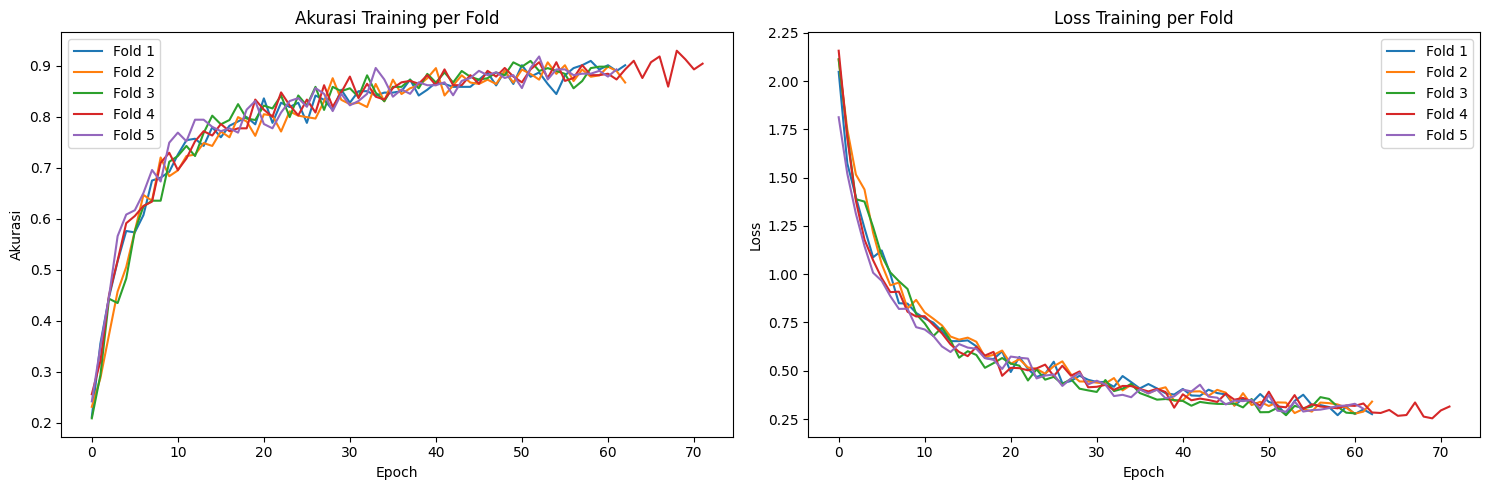

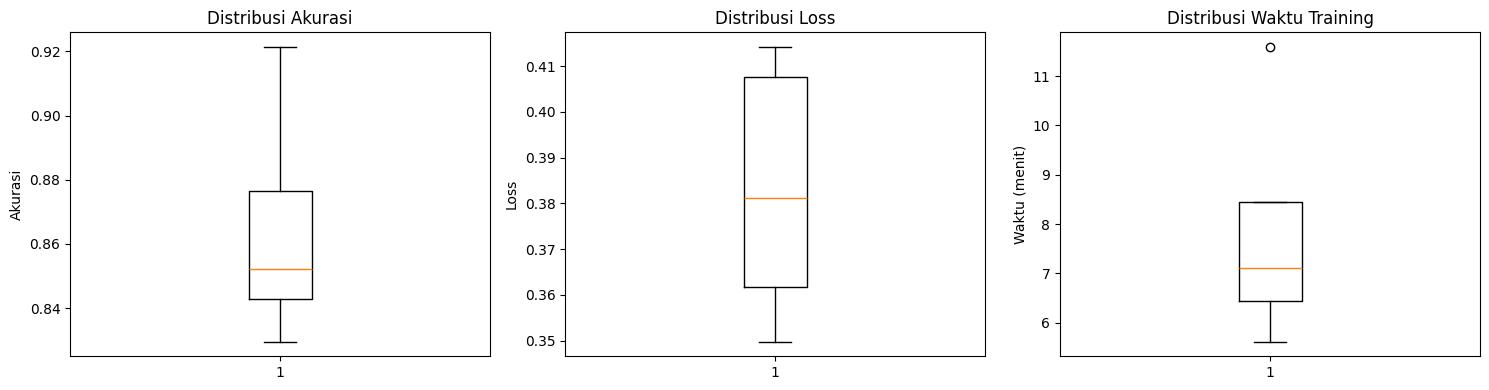

In [21]:
# Analisis hasil Cross Validation
print("\nRingkasan Hasil Cross Validation:")
print(f"├── Rata-rata Akurasi: {np.mean(fold_accuracies):.4f} (±{np.std(fold_accuracies):.4f})")
print(f"├── Rata-rata Loss: {np.mean(fold_losses):.4f} (±{np.std(fold_losses):.4f})")

# Analisis waktu
fold_durations_minutes = np.array(fold_durations) / 60  # Konversi ke menit
mean_duration = np.mean(fold_durations)
std_duration = np.std(fold_durations)

print("\nAnalisis Waktu Training:")
print(f"├── Rata-rata waktu per fold: {mean_duration/60:.2f} menit (±{std_duration/60:.2f} menit)")
print(f"├── Waktu minimum: {np.min(fold_durations_minutes):.2f} menit")
print(f"├── Waktu maksimum: {np.max(fold_durations_minutes):.2f} menit")
print(f"└── Total waktu: {np.sum(fold_durations_minutes):.2f} menit")

# Visualisasi hasil cross validation
plt.figure(figsize=(15, 5))

# Plot akurasi semua fold
plt.subplot(1, 2, 1)
for fold, history in enumerate(fold_histories):
    plt.plot(history['accuracy'], label=f'Fold {fold+1}')
plt.title('Akurasi Training per Fold')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Plot loss semua fold
plt.subplot(1, 2, 2)
for fold, history in enumerate(fold_histories):
    plt.plot(history['loss'], label=f'Fold {fold+1}')
plt.title('Loss Training per Fold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Box plot untuk distribusi akurasi, loss, dan waktu
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.boxplot(fold_accuracies)
plt.title('Distribusi Akurasi')
plt.ylabel('Akurasi')

plt.subplot(1, 3, 2)
plt.boxplot(fold_losses)
plt.title('Distribusi Loss')
plt.ylabel('Loss')

plt.subplot(1, 3, 3)
plt.boxplot(fold_durations_minutes)
plt.title('Distribusi Waktu Training')
plt.ylabel('Waktu (menit)')

plt.tight_layout()
plt.show()

# Evaluasi Model Terbaik
Setelah mendapatkan model terbaik dari proses K-Fold Cross Validation, kita akan melakukan evaluasi menyeluruh terhadap model tersebut menggunakan data test.

In [22]:
# 1. Evaluasi Dasar Model Terbaik
print(f"{'='*50}")
print("Evaluasi Model Terbaik pada Data Test")
print(f"{'='*50}")

# Muat model terbaik yang telah disimpan
print("\nMemuat model terbaik dari file...")
best_model = load_model(MODEL_NAME)
print(f"✓ Model berhasil dimuat dari '{MODEL_NAME}'")

# Evaluasi model pada data test
print("\nMengevaluasi model pada data test...")
test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)

# Tampilkan hasil evaluasi
print(f"\nMetrik Dasar:")
print(f"├── Akurasi: {test_acc:.2%}")
print(f"└── Loss: {test_loss:.4f}")

Evaluasi Model Terbaik pada Data Test

Memuat model terbaik dari file...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


✓ Model berhasil dimuat dari 'revisi.h5'

Mengevaluasi model pada data test...

Metrik Dasar:
├── Akurasi: 91.53%
└── Loss: 0.3226

Metrik Dasar:
├── Akurasi: 91.53%
└── Loss: 0.3226


# Evaluasi Model Terbaik pada Training Data
Di bagian ini kita akan melihat seberapa baik model terbaik yang telah disimpan dalam melakukan prediksi pada data training. Hal ini penting untuk membandingkan dengan performa pada data validasi dan test untuk menganalisis kemungkinan overfitting.

# Analisis Performa Detail
Kita akan melakukan analisis mendalam terhadap performa model menggunakan berbagai metrik dan visualisasi:
1. Classification Report - Metrik detail per kelas
2. Confusion Matrix - Visualisasi prediksi vs aktual
3. ROC Curve & AUC Score (untuk setiap kelas)
4. Precision-Recall Curve

Analisis Detail Model Terbaik

Membuat prediksi untuk data test...
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/stepWARNING:tensorflow:5 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001FFAF50D120> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step

1. Classification Report
----------------------------------------
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        12
   leaf curl       1.00      1.00      1.00        16
   leaf spot       0.83      0.91      0.87        11
    whitefly       0.73      0.80      0.76        10
   yellowish       1.00      0.80      0.89        10

    accuracy                           0.92        59
   macro avg       0.91      0.90      0.90        59
weighted avg       0.92      0.92      0.92        59


2. Confusion Matrix
----------------------------------------

1. Classification Report
----------------------------------------
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        12
   leaf curl       1.00      1.00      1.00        16
   leaf spot       0.83      0.91      0.87        11
    whitefly       0

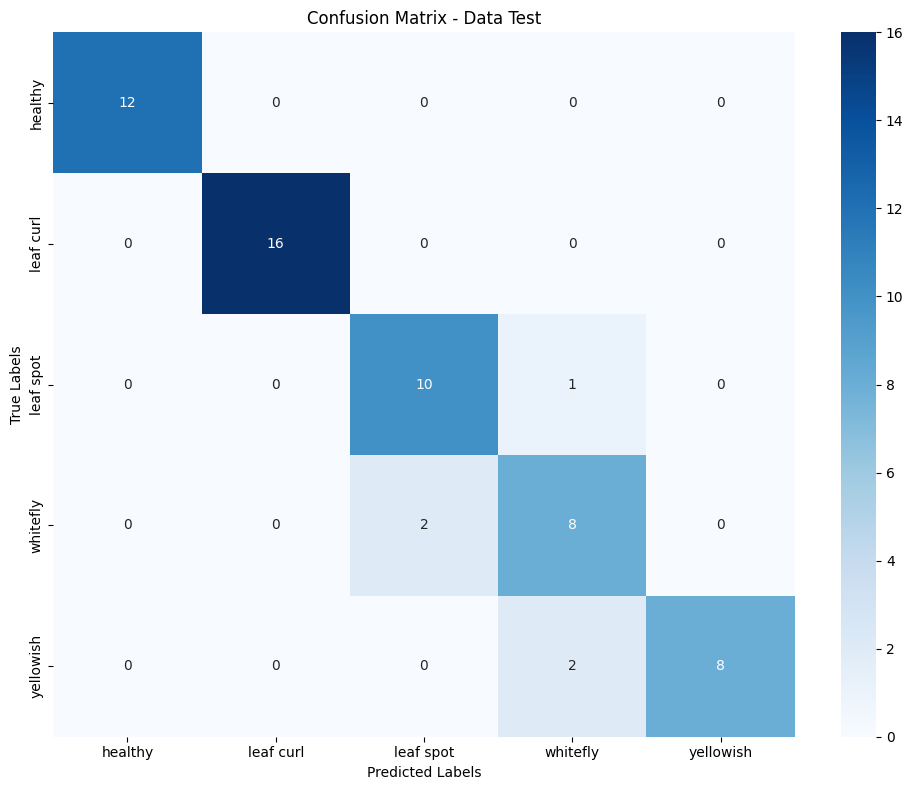


3. ROC Curves dan AUC Scores
----------------------------------------


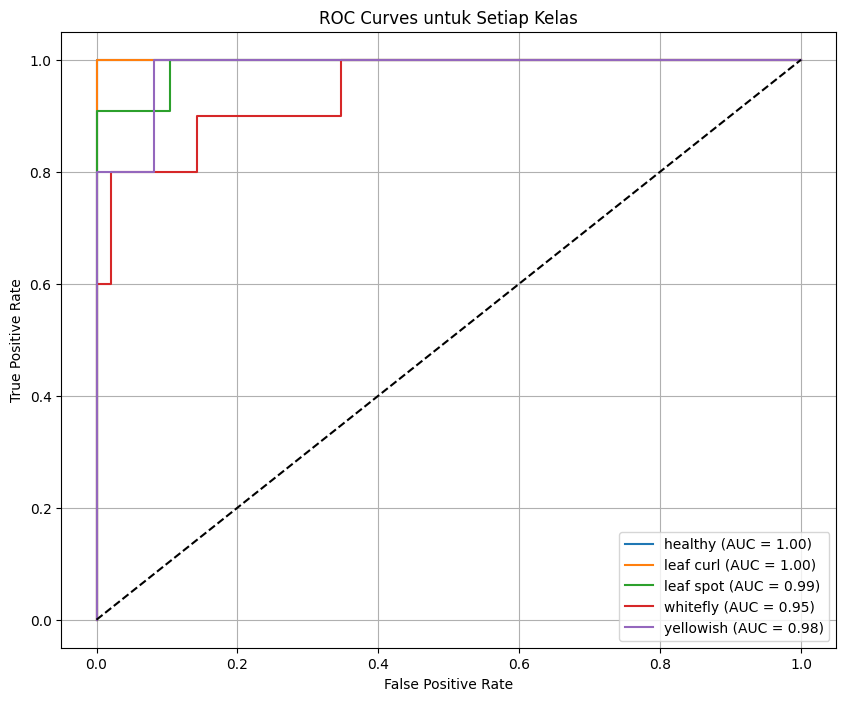


4. Precision-Recall Curves
----------------------------------------


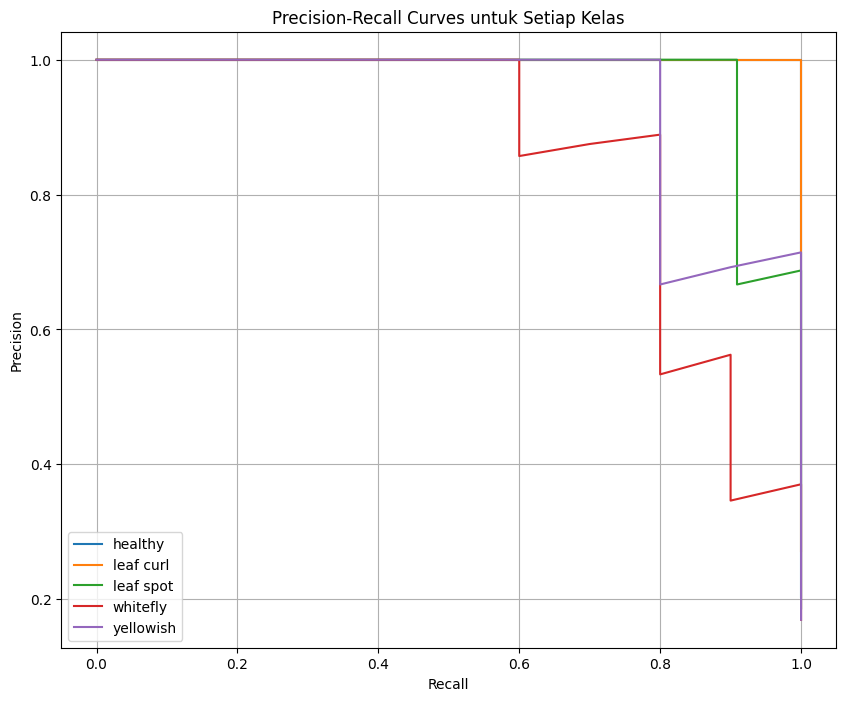


5. Statistik Detail per Kelas
----------------------------------------

Kelas: healthy
├── Jumlah sampel: 12
├── Akurasi: 100.00%
└── Jumlah prediksi benar: 12 dari 12

Kelas: leaf curl
├── Jumlah sampel: 16
├── Akurasi: 100.00%
└── Jumlah prediksi benar: 16 dari 16

Kelas: leaf spot
├── Jumlah sampel: 11
├── Akurasi: 90.91%
└── Jumlah prediksi benar: 10 dari 11

Kelas: whitefly
├── Jumlah sampel: 10
├── Akurasi: 80.00%
└── Jumlah prediksi benar: 8 dari 10

Kelas: yellowish
├── Jumlah sampel: 10
├── Akurasi: 80.00%
└── Jumlah prediksi benar: 8 dari 10


In [23]:
# 2. Analisis Detail Performa Model
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns

print(f"{'='*50}")
print("Analisis Detail Model Terbaik")
print(f"{'='*50}")

# Hitung prediksi untuk data test
print("\nMembuat prediksi untuk data test...")
steps = int(np.ceil(test_generator.samples / BATCH_SIZE))
Y_pred_proba = best_model.predict(test_generator, steps=steps)
Y_pred = np.argmax(Y_pred_proba, axis=1)
Y_true = test_generator.classes

# 1. Classification Report
print("\n1. Classification Report")
print("-" * 40)
print(classification_report(Y_true, Y_pred, target_names=CLASSES))

# 2. Confusion Matrix
print("\n2. Confusion Matrix")
print("-" * 40)
cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Data Test')
plt.tight_layout()
plt.show()

# 3. ROC Curves dan AUC Scores
print("\n3. ROC Curves dan AUC Scores")
print("-" * 40)
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(CLASSES):
    # Buat label biner untuk kelas saat ini
    y_true_binary = (Y_true == i).astype(int)
    y_pred_binary = Y_pred_proba[:, i]
    
    # Hitung ROC curve dan AUC
    fpr, tpr, _ = roc_curve(y_true_binary, y_pred_binary)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')
    
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves untuk Setiap Kelas')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 4. Precision-Recall Curves
print("\n4. Precision-Recall Curves")
print("-" * 40)
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(CLASSES):
    y_true_binary = (Y_true == i).astype(int)
    y_pred_binary = Y_pred_proba[:, i]
    
    precision, recall, _ = precision_recall_curve(y_true_binary, y_pred_binary)
    plt.plot(recall, precision, label=f'{class_name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves untuk Setiap Kelas')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# 5. Statistik per Kelas
print("\n5. Statistik Detail per Kelas")
print("-" * 40)
for i, class_name in enumerate(CLASSES):
    class_mask = Y_true == i
    class_correct = Y_pred[class_mask] == i
    class_acc = np.mean(class_correct)
    class_samples = np.sum(class_mask)
    
    print(f"\nKelas: {class_name}")
    print(f"├── Jumlah sampel: {class_samples}")
    print(f"├── Akurasi: {class_acc:.2%}")
    print(f"└── Jumlah prediksi benar: {np.sum(class_correct)} dari {class_samples}")

In [ ]:
# Visualisasi Learning Curves Model Terbaik
print(f"{'='*70}")
print("VISUALISASI LEARNING CURVES MODEL TERBAIK (revisi.h5)")
print(f"{'='*70}")

# Plot learning curves
plt.figure(figsize=(15, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
best_history = fold_histories[np.argmax(fold_accuracies)]
plt.plot(best_history['accuracy'], label='Training', color='#2ecc71')
plt.plot(best_history['val_accuracy'], label='Validation', color='#3498db')
plt.title('Learning Curves - Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(best_history['loss'], label='Training', color='#2ecc71')
plt.plot(best_history['val_loss'], label='Validation', color='#3498db')
plt.title('Learning Curves - Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Analisis hasil training
print("\nAnalisis Training Model Terbaik:")
print("-" * 40)

# Mencari epoch terbaik
best_epoch = np.argmin(best_history['val_loss'])
best_val_loss = min(best_history['val_loss'])
best_val_acc = max(best_history['val_accuracy'])

print(f"1. Performa Terbaik:")
print(f"   ├── Epoch terbaik: {best_epoch + 1}")
print(f"   ├── Akurasi validasi tertinggi: {best_val_acc:.2%}")
print(f"   └── Loss validasi terendah: {best_val_loss:.4f}")

# Analisis konvergensi
final_train_acc = best_history['accuracy'][-1]
final_train_loss = best_history['loss'][-1]
final_val_acc = best_history['val_accuracy'][-1]
final_val_loss = best_history['val_loss'][-1]

print(f"\n2. Hasil Akhir Training:")
print(f"   ├── Akurasi training: {final_train_acc:.2%}")
print(f"   ├── Loss training: {final_train_loss:.4f}")
print(f"   ├── Akurasi validasi: {final_val_acc:.2%}")
print(f"   └── Loss validasi: {final_val_loss:.4f}")

# Analisis overfitting
acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

print(f"\n3. Analisis Overfitting:")
print(f"   ├── Gap akurasi (train-val): {acc_gap:.2%}")
print(f"   └── Gap loss (val-train): {loss_gap:.4f}")

if acc_gap > 0.05 or loss_gap > 0.5:
    print("\n⚠️ Peringatan: Ada indikasi overfitting")
    print("Model menunjukkan gap yang signifikan antara")
    print("performa training dan validasi.")
else:
    print("\n✅ Model menunjukkan generalisasi yang baik")
    print("dengan gap yang wajar antara training dan validasi.")

# Evaluasi Akurasi Model Terbaik
Bagian ini khusus mengevaluasi performa model terbaik yang telah disimpan (revisi.h5) pada data training, validasi, dan testing.

Evaluasi Komprehensif Model Terbaik

1. Performa pada Data Training
----------------------------------------
├── Akurasi Training: 94.13%
└── Loss Training: 0.2115

2. Performa pada Data Validasi
----------------------------------------
├── Akurasi Training: 94.13%
└── Loss Training: 0.2115

2. Performa pada Data Validasi
----------------------------------------
├── Akurasi Validasi: 94.44%
└── Loss Validasi: 0.1677

3. Performa pada Data Test
----------------------------------------
├── Akurasi Validasi: 94.44%
└── Loss Validasi: 0.1677

3. Performa pada Data Test
----------------------------------------
├── Akurasi Test: 91.53%
└── Loss Test: 0.3226

4. Analisis Overfitting
----------------------------------------
Gap Analysis:
├── Training-Validation Gap: -0.31%
└── Validation-Test Gap: 2.92%

Model menunjukkan generalisasi yang baik!
├── Akurasi Test: 91.53%
└── Loss Test: 0.3226

4. Analisis Overfitting
----------------------------------------
Gap Analysis:
├── Training-Validation

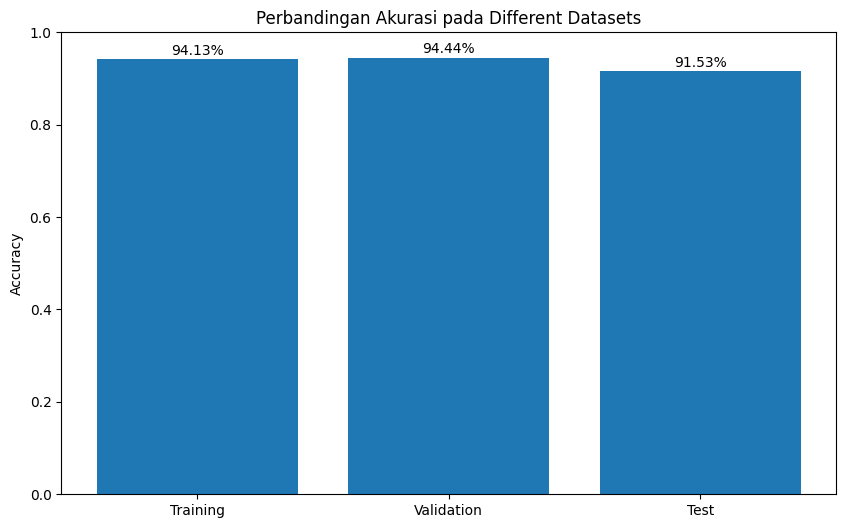

In [30]:
# Evaluasi Komprehensif Model Terbaik
print(f"{'='*50}")
print("Evaluasi Komprehensif Model Terbaik")
print(f"{'='*50}")

# Evaluasi pada data training
print("\n1. Performa pada Data Training")
print("-" * 40)
train_loss, train_acc = best_model.evaluate(train_generator, verbose=0)
print(f"├── Akurasi Training: {train_acc:.2%}")
print(f"└── Loss Training: {train_loss:.4f}")

# Evaluasi pada data validasi
print("\n2. Performa pada Data Validasi")
print("-" * 40)
val_loss, val_acc = best_model.evaluate(val_generator, verbose=0)
print(f"├── Akurasi Validasi: {val_acc:.2%}")
print(f"└── Loss Validasi: {val_loss:.4f}")

# Evaluasi pada data test
print("\n3. Performa pada Data Test")
print("-" * 40)
test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)
print(f"├── Akurasi Test: {test_acc:.2%}")
print(f"└── Loss Test: {test_loss:.4f}")

# Analisis Overfitting
print("\n4. Analisis Overfitting")
print("-" * 40)
train_val_gap = train_acc - val_acc
val_test_gap = val_acc - test_acc

print("Gap Analysis:")
print(f"├── Training-Validation Gap: {train_val_gap:.2%}")
print(f"└── Validation-Test Gap: {val_test_gap:.2%}")

if abs(train_val_gap) > 0.05:
    print("\nPeringatan: Gap antara training dan validation cukup besar")
    print("Kemungkinan ada overfitting. Pertimbangkan:")
    print("1. Menambah augmentasi data")
    print("2. Meningkatkan dropout rate")
    print("3. Menambah regularisasi L2")
    print("4. Mengurangi kompleksitas model")
else:
    print("\nModel menunjukkan generalisasi yang baik!")

# Visualisasi perbandingan akurasi
plt.figure(figsize=(10, 6))
accuracies = [train_acc, val_acc, test_acc]
labels = ['Training', 'Validation', 'Test']
plt.bar(labels, accuracies)
plt.title('Perbandingan Akurasi pada Different Datasets')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center')
plt.show()

# Evaluasi Komprehensif Model Terbaik
Kita akan melakukan evaluasi menyeluruh terhadap model terbaik, membandingkan performa pada data training, validasi, dan test untuk memastikan tidak ada overfitting yang signifikan.

# Uji Coba Prediksi pada Gambar Tunggal
Terakhir, kita buat fungsi untuk menguji model seperti pada aplikasi nyata: memasukkan satu gambar dan melihat apa hasil prediksinya.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


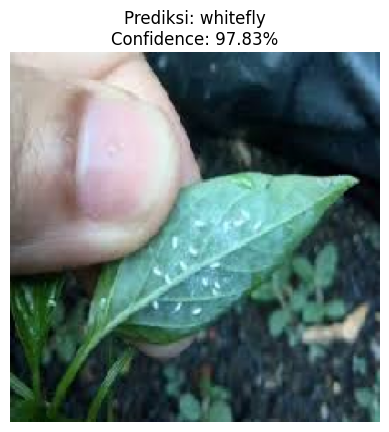

('whitefly', np.float32(0.9783447))

In [31]:
# Fungsi untuk memprediksi gambar tunggal

def predict_single_image(img_path, model, class_names, threshold=0.5):
    """
    Fungsi untuk memprediksi kelas dari sebuah gambar tunggal
    
    Parameters:
    img_path (str): Path ke file gambar
    model: Model Keras yang sudah dilatih
    class_names (list): Daftar nama kelas
    threshold (float): Threshold confidence untuk klasifikasi (default: 0.5)
    
    Returns:
    tuple: (predicted_class, confidence) - Kelas yang diprediksi dan nilai confidence
    """
    try:
        # Load dan preprocess gambar
        img = tf.keras.preprocessing.image.load_img(
            img_path, 
            target_size=(IMAGE_SIZE, IMAGE_SIZE)
        )
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        
        # Lakukan prediksi
        pred = model.predict(img_array)
        class_idx = np.argmax(pred[0])
        confidence = pred[0][class_idx]
        
        # Tampilkan gambar dengan hasil prediksi
        plt.imshow(img)
        if confidence < threshold:
            predicted_class = "Tidak Dikenali (Confidence Rendah)"
            title_text = f'Prediksi: {predicted_class}\nConfidence: {confidence:.2%}'
        else:
            predicted_class = class_names[class_idx]
            title_text = f'Prediksi: {predicted_class}\nConfidence: {confidence:.2%}'
        
        plt.title(title_text)
        plt.axis('off')
        plt.show()
        
        return predicted_class, confidence
        
    except FileNotFoundError:
        print(f"Error: File gambar tidak ditemukan di path '{img_path}'")
        return None, None
    except Exception as e:
        print(f"Terjadi error saat memproses gambar: {e}")
        return None, None

# Contoh penggunaan fungsi prediksi
test_image_path = 'image.png'  # Path ke gambar yang akan diprediksi
predict_single_image(test_image_path, best_model, CLASSES, threshold=0.5)